In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
from scipy.fft import fft, fftfreq
import xarray as xr

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Probe_analysis')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# Vertical velocity from PIV analysis
## Made from `/PIV/plate_top/...`
* IR: 16 x 16 px
* Overlap = 50%
* SA = 16 x 16 px
* stepsize = 1
* dt = 0.008 s
* sig2noise threshold = 1.2
* max_iter = 10
* kernel_size = 2

In [2]:
base_path = '/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/'
# Results from PIV processing
piv_a03_r1 = xr.open_dataset(base_path + 'f14a03_zoom_res_r1.nc')
piv_a03_r2 = xr.open_dataset(base_path + 'f14a03_zoom_res_r2.nc')
piv_a03_r3 = xr.open_dataset(base_path + 'f14a03_zoom_res_r3.nc')

piv_a02_r1 = xr.open_dataset(base_path + 'f14a02_zoom_res_r1.nc')
piv_a02_r2 = xr.open_dataset(base_path + 'f14a02_zoom_res_r2.nc')
piv_a02_r3 = xr.open_dataset(base_path + 'f14a02_zoom_res_r3.nc')

piv_a01_r1 = xr.open_dataset(base_path + 'f14a01_zoom_res_r1.nc')
piv_a01_r2 = xr.open_dataset(base_path + 'f14a01_zoom_res_r2.nc')
piv_a01_r3 = xr.open_dataset(base_path + 'f14a01_zoom_res_r3.nc')

base_path = '/Users/kjesta/Desktop/LABDATA/Calculated_amps/'
# Results from probe analysis
prb_a03_p = pd.read_csv(base_path + '20cm_f14_a03_p005_results.csv')
prb_a02_p = pd.read_csv(base_path + '20cm_f14_a02_p005_results.csv')
prb_a01_p = pd.read_csv(base_path + '20cm_f14_a01_p005_results.csv')

prb_a03 = pd.read_csv(base_path + '20cm_f14_a03_results.csv')
prb_a02 = pd.read_csv(base_path + '20cm_f14_a02_results.csv')
prb_a01 = pd.read_csv(base_path + '20cm_f14_a01_results.csv')

# Post-processed probe data
eta_03_p = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Processed_files/20cm_f14_a03_p005_r1_processed.csv')
eta_02_p = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Processed_files/20cm_f14_a02_p005_r1_processed.csv')
eta_01_p = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Processed_files/20cm_f14_a01_p005_r1_processed.csv')

eta_03 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Processed_files/20cm_f14_a03_r1_processed.csv')
eta_02 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Processed_files/20cm_f14_a02_r1_processed.csv')
eta_01 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Processed_files/20cm_f14_a01_r1_processed.csv')

## The theoretical values
#### Damping coefficient
$\alpha_{theory} = \alpha_{Weber}/(1 + Q)$ 

$Q = \frac{(3 - D/H)gDh^4k^2}{288\nu^2}$ 

$ \alpha_{Weber} = kh^2\omega(D-H)/(24H\nu)$ 

#### Robin parameter
$R_{theory} = (2H\alpha_{theory})/k$

#### Vertical velocity at z = -H

$\operatorname{Re}\{\bar{w}(z=-H)\} = -gh^2(D-H)Ae^{-\alpha x} \frac{\beta}{144\nu^2 + h^4\omega^2}$

where A is the real amplitude of the free surface ($\eta$) and, $\beta = 12\nu(k^2\cos\theta - 2\alpha k\sin\theta) - h^2\omega(k^2\sin\theta + 2\alpha k\cos\theta)$ with the phase $\theta = kx -\omega t$.

In [3]:
start = piv_a03_r1.time.values[0]
end = piv_a03_r1.time.values[-1]
time_piv = piv_a03_r1.time.values

In [4]:
# Pick out the same time as the PIV data for comparison. 
eta_all_03_p = eta_03_p[(eta_03_p['time'] >= start) & (eta_03_p['time'] <= end)]
eta03_p = eta_all_03_p['P_0'].values * -1

eta_all_02_p = eta_02_p[(eta_02_p['time'] >= start) & (eta_02_p['time'] <= end)]
eta02_p = eta_all_02_p['P_0'].values * -1

eta_all_01_p = eta_01_p[(eta_01_p['time'] >= start) & (eta_01_p['time'] <= end)]
eta01_p = eta_all_01_p['P_0'].values * -1

In [5]:
# Pick out the same time as the PIV data for comparison. 
eta_all_03 = eta_03[(eta_03['time'] >= start) & (eta_03['time'] <= end)]
eta03 = eta_all_03['P_0'].values * -1

eta_all_02 = eta_02[(eta_02['time'] >= start) & (eta_02['time'] <= end)]
eta02 = eta_all_02['P_0'].values * -1

eta_all_01 = eta_01[(eta_01['time'] >= start) & (eta_01['time'] <= end)]
eta01 = eta_all_01['P_0'].values * -1

In [6]:
f = 1.4  # frequency (Hz)
omega = 2 * np.pi * f  # angular frequency (rad/s)
g = 9.81  # gravitational acceleration (m/s^2)
nu = 1e-6  # kinematic viscosity of water (m^2/s)
D = 0.2  # water height (m)
H = 0.15  # depth of plate top (m)
h = 0.01  # distance between plates (m)
k = estimate_wavenumber(f, D)

a_theory, a_weber = spatial_damping_coefficient(k, D, H, h)

# Robin parameter
R_theory = robin_parameter(H, a_theory, k)
R_weber = robin_parameter(H, a_weber, k)

In [7]:
# Amplitudes measured at first probe position
# Should be unaffected by the presence of plates
amp_03 = list(prb_a03['Amp_obs_P0'].values) + list(prb_a03_p['Amp_obs_P0'].values)
amp_02 = list(prb_a02['Amp_obs_P0'].values) + list(prb_a02_p['Amp_obs_P0'].values)
amp_01 = list(prb_a01['Amp_obs_P0'].values) + list(prb_a01_p['Amp_obs_P0'].values)

In [8]:
A03 = np.round(np.mean(amp_03), 3)
A02 = np.round(np.mean(amp_02), 3)
A01 = np.round(np.mean(amp_01), 3)

In [28]:
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])

In [29]:
x = 8.06 - x_probe_pos[0]
t = time_piv

# Vertical velocity at z=-H
w_bar_theory_a03 = vertical_velocity(A03, D, H, f, a_theory, k, h, x, t)
w_bar_theory_a02 = vertical_velocity(A02, D, H, f, a_theory, k, h, x, t)
w_bar_theory_a01 = vertical_velocity(A01, D, H, f, a_theory, k, h, x, t)

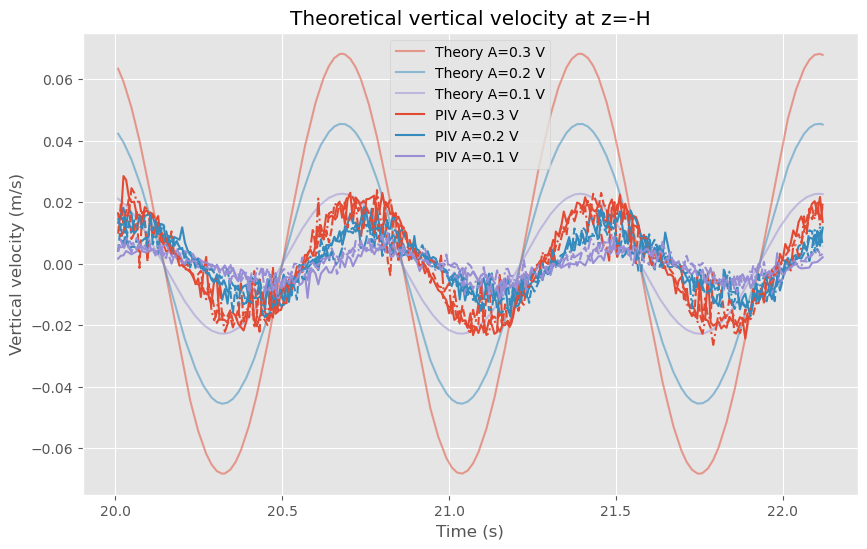

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t, w_bar_theory_a03, color='C0', label='Theory A=0.3 V', alpha=0.5)
ax.plot(t, w_bar_theory_a02, color='C1', label='Theory A=0.2 V', alpha=0.5)
ax.plot(t, w_bar_theory_a01, color='C2', label='Theory A=0.1 V', alpha=0.5)

ax.plot(t, piv_a03_r1['w'][:, -1], color='C0', label='PIV A=0.3 V')
ax.plot(t, piv_a02_r1['w'][:, -1], color='C1', label='PIV A=0.2 V')
ax.plot(t, piv_a01_r1['w'][:, -1], color='C2', label='PIV A=0.1 V')

ax.plot(t, piv_a03_r2['w'][:, -1], color='C0', linestyle='--')
ax.plot(t, piv_a02_r2['w'][:, -1], color='C1', linestyle='--')
ax.plot(t, piv_a01_r2['w'][:, -1], color='C2', linestyle='--')

ax.plot(t, piv_a03_r3['w'][:, -1], color='C0', linestyle='-.')
ax.plot(t, piv_a02_r3['w'][:, -1], color='C1', linestyle='-.')
ax.plot(t, piv_a01_r3['w'][:, -1], color='C2', linestyle='-.')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Vertical velocity (m/s)')
ax.set_title('Theoretical vertical velocity at z=-H')
ax.legend()

## Observed values

Text(0.5, 0.98, 'Difference between runs')

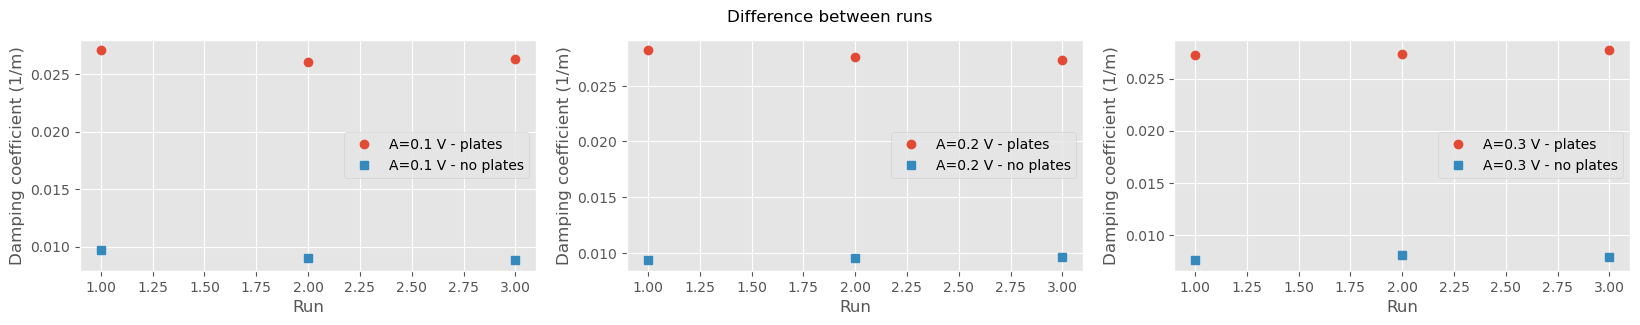

In [11]:
# Difference between runs
fig, ax = plt.subplots(1, 3, figsize=(20, 3))
ax[0].plot([1, 2, 3], prb_a01_p['Alpha_obs'].values, 'o', label='A=0.1 V - plates')
ax[0].plot([1, 2, 3], prb_a01['Alpha_obs'].values, 's', label='A=0.1 V - no plates')

ax[1].plot([1, 2, 3], prb_a02_p['Alpha_obs'].values, 'o', label='A=0.2 V - plates')
ax[1].plot([1, 2, 3], prb_a02['Alpha_obs'].values, 's', label='A=0.2 V - no plates')

ax[2].plot([1, 2, 3], prb_a03_p['Alpha_obs'].values, 'o', label='A=0.3 V - plates')
ax[2].plot([1, 2, 3], prb_a03['Alpha_obs'].values, 's', label='A=0.3 V - no plates')

for a in ax:
    a.set_xlabel('Run')
    a.set_ylabel('Damping coefficient (1/m)')
    a.legend()

fig.suptitle('Difference between runs')

In [12]:
# Subtracting the walls
a_obs_a03 = np.mean(prb_a03_p['Alpha_obs'].values) - np.mean(prb_a03['Alpha_obs'].values)
a_obs_a02 = np.mean(prb_a02_p['Alpha_obs'].values) - np.mean(prb_a02['Alpha_obs'].values)
a_obs_a01 = np.mean(prb_a01_p['Alpha_obs'].values) - np.mean(prb_a01['Alpha_obs'].values)

In [13]:
# Finding the Robin parameter from the probe data
R_a03 = robin_parameter(H, a_obs_a03, k)
R_a02 = robin_parameter(H, a_obs_a02, k)
R_a01 = robin_parameter(H, a_obs_a01, k)

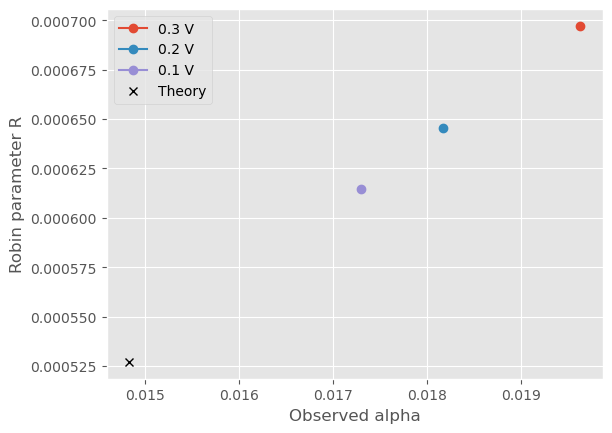

In [14]:
plt.plot(a_obs_a03, R_a03, 'o-', label='0.3 V')
plt.plot(a_obs_a02, R_a02, 'o-', label='0.2 V')
plt.plot(a_obs_a01, R_a01, 'o-', label='0.1 V')

plt.plot(a_theory, R_theory, 'kx', label='Theory')

plt.xlabel('Observed alpha')
plt.ylabel('Robin parameter R')
plt.legend()